Example showing how to use the arbitrary dispersion function. This code is useful for cases where dispersion engineering is used to generate velocity matching which cancels out the frequency-linear term in the phase-mismatch $(i.e. \Delta k(\omega.\omega')\approx \mathcal{O}(\omega^2,\omega'^2,\omega\omega'))$. Give 2 examples: "fake example with made-up dispersion", second using dispersive data previously generated

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.spdc import SPulsed_arb

We initialize the data. Note that here we use dispersive date obtained from dispersion engineering. Link LNO paper. 

In [2]:
#Renormalize such that units are in nm and THz

l = 0.01 * 1e9
ww = np.load('data/frequency.npy') * 1e-12
dw = np.abs(ww[1]-ww[0])
ks = np.load('data/ks.npy') * 1e-9
kp_w = np.load('data/kp_w.npy') * 1e-9

In [3]:
sig_w = 33.3
pump_w = 1e-3*np.exp(-((ww + ww[:, np.newaxis]) ** 2) / (2 * sig_w**2)) / np.power(
    np.pi * (sig_w) ** 2, 1 / 4
)

# Interaction strength and spatial discretization
Np = 5.26e-10  # low-gain: 1.857e-11. Currently set to high-gain
gamma = np.sqrt(Np / (
    2 * np.pi * 0.442**3))


In [6]:
# Spatial grid and domain
Ndomain = 1000  # Number of spatial points for non-linear/crystal grid
dz = l / Ndomain
z_list = np.linspace(-l/2,l/2-dz,1000)
domain = np.asarray([1]*len(z_list))


In [7]:
T_arb, J_arb, Ns_arb, K_arb, M_arb, Nums_arb, Numi_arb = SPulsed_arb(ks, ks, kp_w, gamma, dw, z_list, domain, pump_w)

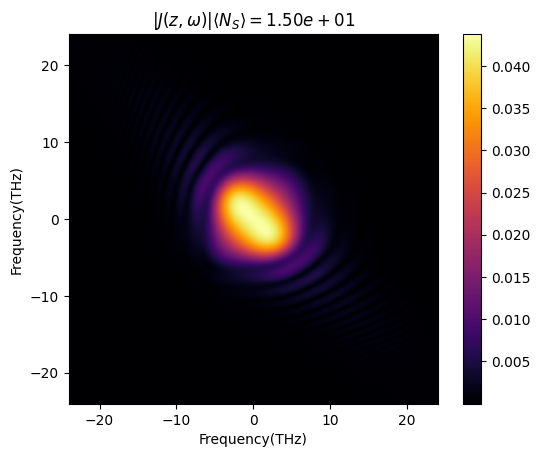

In [8]:
# Generating plot for the abs(JSA) in terms of frequency(f)
fig, ax = plt.subplots()
im = ax.imshow(
    np.abs(J_arb),
    cmap="inferno",
    origin="lower",
    extent=[
        ww[0] / (2 * np.pi),
        ww[-1] / (2 * np.pi),
        ww[0] / (2 * np.pi),
        ww[-1] / (2 * np.pi),
    ],
)
ax.set_xlabel("Frequency(THz)")
ax.set_ylabel("Frequency(THz)")
ax.set_title(r"$|J(z, \omega)|    \langle N_{S} \rangle = %1.2e $" % Ns_arb)
plt.colorbar(im, orientation="vertical")
plt.show()